In [3]:
%pip install xgboost lightgbm catboost

  Using cached xgboost-3.2.0-py3-none-macosx_12_0_arm64.whl.metadata (2.1 kB)
  Using cached lightgbm-4.6.0-py3-none-macosx_12_0_arm64.whl.metadata (17 kB)
  Using cached graphviz-0.21-py3-none-any.whl.metadata (12 kB)
Using cached xgboost-3.2.0-py3-none-macosx_12_0_arm64.whl (2.3 MB)
Using cached lightgbm-4.6.0-py3-none-macosx_12_0_arm64.whl (1.6 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 28.8/28.8 MB 2.0 MB/s  0:00:14 eta 0:00:010:00:01
Using cached graphviz-0.21-py3-none-any.whl (47 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [catboost]━━ 3/4 [catboost]
Note: you may need to restart the kernel to use updated packages.


In [8]:
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.tree import DecisionTreeRegressor

import xgboost as xgb
import lightgbm as lgb
import catboost as cb

sns.set_theme(style="whitegrid")

In [9]:
data = fetch_california_housing()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target

print(X.head())
print()

X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=42)

print(f"Размер обучающей выборки: {X_train.shape[0]}")
print(f"Размер валидационной выборки: {X_val.shape[0]}")
print(f"Размер тестовой выборки: {X_test.shape[0]}")

   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  
0    -122.23  
1    -122.22  
2    -122.24  
3    -122.25  
4    -122.25  

Размер обучающей выборки: 12384
Размер валидационной выборки: 4128
Размер тестовой выборки: 4128


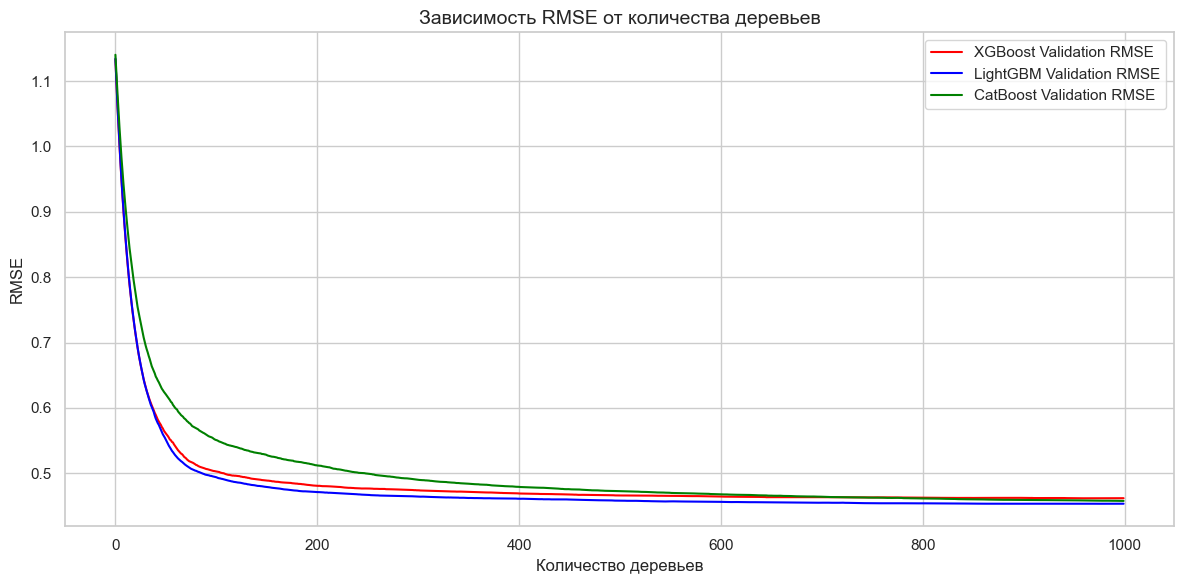

In [10]:
MAX_TREES = 1000
LEARNING_RATE = 0.05

xgb_model = xgb.XGBRegressor(n_estimators=MAX_TREES, learning_rate=LEARNING_RATE, random_state=42)
xgb_model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
xgb_rmse = xgb_model.evals_result()['validation_0']['rmse']

lgb_model = lgb.LGBMRegressor(n_estimators=MAX_TREES, learning_rate=LEARNING_RATE, random_state=42, verbose=-1)
lgb_model.fit(X_train, y_train, eval_set=[(X_val, y_val)], eval_metric='rmse')
lgb_metric_key = list(lgb_model.evals_result_['valid_0'].keys())[0]
lgb_rmse = lgb_model.evals_result_['valid_0'][lgb_metric_key]

cb_model = cb.CatBoostRegressor(iterations=MAX_TREES, learning_rate=LEARNING_RATE, eval_metric='RMSE', random_seed=42)
cb_model.fit(X_train, y_train, eval_set=(X_val, y_val), verbose=False)
cb_rmse = cb_model.evals_result_['learn']['RMSE']
cb_val_rmse = cb_model.evals_result_['validation']['RMSE']

plt.figure(figsize=(12, 6))
plt.plot(xgb_rmse, label='XGBoost Validation RMSE', color='red')
plt.plot(lgb_rmse, label='LightGBM Validation RMSE', color='blue')
plt.plot(cb_val_rmse, label='CatBoost Validation RMSE', color='green')

plt.title('Зависимость RMSE от количества деревьев', fontsize=14)
plt.xlabel('Количество деревьев', fontsize=12)
plt.ylabel('RMSE', fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()

In [11]:
SELECTED_N_ESTIMATORS = 400

In [12]:
class MyBoost:
    def __init__(self, n=SELECTED_N_ESTIMATORS, lr=0.05, depth=7, subsample=1.0, colsample_bytree=1.0, seed=42) -> None:
        self.n = n
        self.lr = lr
        self.depth = depth
        self.subsample = subsample
        self.colsample_bytree = colsample_bytree
        self.seed = seed
        self.trees = []
        self.features_per_tree = []
        self.feature_importances_ = None

    def fit(self, X, y):
        if isinstance(X, pd.DataFrame):
            cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
            if cat_cols:
                X = pd.get_dummies(X, columns=cat_cols, drop_first=True, dtype=int)
            self.feature_names_out_ = X.columns.tolist()
            X_np = X.values
        else:
            X_np = np.array(X)
            self.feature_names_out_ = [f"feature_{i}" for i in range(X_np.shape[1])]
            
        y_np = y.values if isinstance(y, pd.Series) else np.array(y)
        
        self.initial_leaf = y_np.mean()
        predictions = np.zeros(len(y_np)) + self.initial_leaf
        
        n_samples, n_features = X_np.shape
        rng = np.random.default_rng(self.seed)
        
        all_tree_importances = []

        for _ in range(self.n):
            antigrad = y_np - predictions
            
            if self.subsample < 1.0:
                indices = rng.choice(n_samples, size=int(n_samples * self.subsample), replace=False)
                X_curr, antigrad_curr = X_np[indices], antigrad[indices]
            else:
                X_curr, antigrad_curr = X_np, antigrad
                
            if self.colsample_bytree < 1.0:
                features_idx = rng.choice(n_features, size=int(n_features * self.colsample_bytree), replace=False)
            else:
                features_idx = np.arange(n_features)
                
            self.features_per_tree.append(features_idx)
            
            tree = DecisionTreeRegressor(max_depth=self.depth, random_state=self.seed, criterion="friedman_mse")
            tree.fit(X_curr[:, features_idx], antigrad_curr)
            self.trees.append(tree)
            
            predictions += tree.predict(X_np[:, features_idx]) * self.lr
            
            tree_importance = np.zeros(n_features)
            tree_importance[features_idx] = tree.feature_importances_
            all_tree_importances.append(tree_importance)

        self.feature_importances_ = np.mean(all_tree_importances, axis=0)
        self.feature_importances_ /= np.sum(self.feature_importances_)
        
        return self

    def predict(self, samples):
        if isinstance(samples, pd.DataFrame):
            cat_cols = samples.select_dtypes(include=['object', 'category']).columns.tolist()
            if cat_cols:
                samples = pd.get_dummies(samples, columns=cat_cols, drop_first=True, dtype=int)
            samples = samples.reindex(columns=self.feature_names_out_, fill_value=0)
            samples_np = samples.values
        else:
            samples_np = np.array(samples)
            
        predictions = np.zeros(len(samples_np)) + self.initial_leaf
        for i in range(self.n):
            features_idx = self.features_per_tree[i]
            predictions += self.lr * self.trees[i].predict(samples_np[:, features_idx])
        return predictions

In [13]:
from sklearn.model_selection import ParameterGrid

X_train_full = pd.concat([X_train, X_val])
y_train_full = np.concatenate([y_train, y_val])

grid_xgb = {
    'learning_rate': [0.05, 0.1],
    'max_depth':[5, 7],
    'subsample': [0.8, 1.0]
}

grid_lgb = {
    'learning_rate': [0.05, 0.1],
    'num_leaves': [31, 127],
    'subsample':[0.8, 1.0]
}

grid_cat = {
    'learning_rate':[0.05, 0.1],
    'depth': [5, 7],
    'subsample':[0.8, 1.0]
}

def simple_grid_search(model_name, param_grid):
    print(f"--- Запуск Grid Search для {model_name} ---")
    best_rmse = float('inf')
    best_params = None

    start_time = time.time()

    for params in ParameterGrid(param_grid):
        if model_name == 'XGBoost':
            model = xgb.XGBRegressor(**params, n_estimators=SELECTED_N_ESTIMATORS, random_state=42, n_jobs=-1)
        elif model_name == 'LightGBM':
            model = lgb.LGBMRegressor(**params, n_estimators=SELECTED_N_ESTIMATORS, random_state=42, n_jobs=-1, verbose=-1)
        else:
            model = cb.CatBoostRegressor(**params, iterations=SELECTED_N_ESTIMATORS, random_seed=42, thread_count=-1, verbose=0)

        model.fit(X_train, y_train)
        preds = model.predict(X_val)
        rmse = np.sqrt(mean_squared_error(y_val, preds))

        if rmse < best_rmse:
            best_rmse = rmse
            best_params = params

    total_time = time.time() - start_time
    print(f"Лучший Validation RMSE: {best_rmse:.4f}")
    print(f"Лучшие параметры: {best_params}\n")

    return best_params

best_params_dict = {}
best_params_dict['XGBoost'] = simple_grid_search('XGBoost', grid_xgb)
best_params_dict['LightGBM'] = simple_grid_search('LightGBM', grid_lgb)
best_params_dict['CatBoost'] = simple_grid_search('CatBoost', grid_cat)

--- Запуск Grid Search для XGBoost ---
Лучший Validation RMSE: 0.4621
Лучшие параметры: {'learning_rate': 0.05, 'max_depth': 7, 'subsample': 0.8}

--- Запуск Grid Search для LightGBM ---
Лучший Validation RMSE: 0.4557
Лучшие параметры: {'learning_rate': 0.1, 'num_leaves': 31, 'subsample': 0.8}

--- Запуск Grid Search для CatBoost ---
Лучший Validation RMSE: 0.4564
Лучшие параметры: {'depth': 7, 'learning_rate': 0.1, 'subsample': 1.0}



In [14]:
results = []

for name in ['XGBoost', 'LightGBM', 'CatBoost', 'MyBoost']:
    params = best_params_dict.get(name, {})

    if name == 'XGBoost':
        model = xgb.XGBRegressor(n_estimators=SELECTED_N_ESTIMATORS, random_state=42, n_jobs=-1, **params)
    elif name == 'LightGBM':
        model = lgb.LGBMRegressor(n_estimators=SELECTED_N_ESTIMATORS, random_state=42, n_jobs=-1, verbose=-1, **params)
    elif name == 'MyBoost':
        lr = params.get('learning_rate', 0.05)
        depth = params.get('max_depth', 7)
        subsample = params.get('subsample', 0.8)
        model = MyBoost(n=SELECTED_N_ESTIMATORS, lr=lr, depth=depth, subsample=subsample, colsample_bytree=0.8)
    else:
        model = cb.CatBoostRegressor(iterations=SELECTED_N_ESTIMATORS, random_seed=42, thread_count=-1, verbose=0, **params)

    start_time = time.time()
    model.fit(X_train_full, y_train_full)
    train_time = time.time() - start_time

    preds = model.predict(X_test)

    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)

    results.append({
        "Модель": name,
        "Время обучения": round(train_time, 3),
        "MAE": round(mae, 4),
        "RMSE": round(rmse, 4),
        "R2 Score": round(r2, 4)
    })

df_results = pd.DataFrame(results)
display(df_results)

,Модель,Время обучения,MAE,RMSE,R2 Score
0,XGBoost,1.035,0.2912,0.4476,0.8471
1,LightGBM,1.813,0.2862,0.4379,0.8537
2,CatBoost,0.856,0.2967,0.4493,0.8460
3,MyBoost,21.833,0.2907,0.4415,0.8512


## Реализация и результаты

Реализовано в классе `MyBoost`:

* `subsample` — обучать каждое дерево на случайной подвыборке объектов.
* `colsample_bytree` — давать дереву доступ не ко всем признакам, а к случайной доле.
* `feature_importances_` — оценка важности признаков, усреднённая по деревьям с учётом `learning_rate`.
* Нативная поддержка категориальных признаков: если подаёте `pandas.DataFrame`, столбцы типа `object / category` кодируются целочисленно (ordinal) для использования в деревьях.
